<a href="https://colab.research.google.com/github/Alexlimaandre/Algoritmos_FATEC/blob/main/C%C3%B3pia_de_Aula_06_Cole%C3%A7%C3%B5es_(parte_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Coleções (parte 3)**

**Tuplas**

As tuplas são muito semelhantes às listas (vetores). Apenas duas diferenças são significativas:

*   São declaradas usando-se parêntesis ao invés de colchetes;
*   São imutáveis, ou seja, não podem ser alteradas; são mais simples que as listas.

Vamos ver alguns exemplos:

In [ ]:
# Tuplas são imutáveis e são processadas mais rápido!
tupla1 = (1, 2, 3, 4, 5)
print(tupla1)
print(type(tupla1))

(1, 2, 3, 4, 5)
<class 'tuple'>


In [ ]:
print('O primeiro elemento da tupla:', tupla1[0]) # o acesso é idêntico a como fazemos com listas

O primeiro elemento da tupla: 1


Vou tentar **alterar** o primeiro elemento:

In [ ]:
tupla1[0] = 8 # não vai funcionar!!

TypeError: 'tuple' object does not support item assignment

Vou tentar adicionar um elemento com *append*:

In [ ]:
tupla1.append(7) # não vai funcionar!!

Vou tentar **apagar** um elemento:

In [ ]:
del tupla1[3] # não vai funcionar também!!

TypeError: 'tuple' object doesn't support item deletion

Contudo, consigo concatenar tuplas usando **+**. De fato, eu não modifico a tupla, mas crio uma nova a partir de outras duas.

In [ ]:
tupla3 = tupla1 + (7,) # isso funciona!!
print(tupla3)

Repare que a vírgula deixada no final é que realmente informa que (7,) é uma tupla.... Apenas (7) seria encarado como um número inteiro e daria erro. Abaixo mostramos outro modo de criar uma tupla através da palavra reservada **tuple**, que recebe uma coleção e a transforma em tupla.

In [ ]:
tupla2 = tupla1 + tuple([8])
print(tupla2)

**Dicionários**

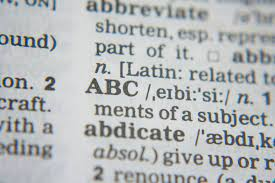

Dicionários são coleções formadas por pares chave - valor. Os dados, ou seja, os valores, são acessados através de chaves que não precisam ser numéricas, como nas listas e tuplas.

Exemplos:

In [ ]:
# Índices não numéricos
# key : value
# {"cpf": "123.123"}
dados = {'cpf':'123.456.789-09',
         'nome':'João da Silva',
         'nascimento':'01/05/2000',
         'genero':'masculino'}
print(dados)
print('O nome do cidadão é', dados['nome'])
print('Seu CPF é', dados['cpf'])

Algumas funções úteis com dicionários:

1.   **del**: exclui um item informando-se a chave
2.   **in**: verifica se uma chave existe no dicionário
3.   **keys( )**: retorna todas as chaves de um dicionário
4.   **values( )**: retorna todos os valores de um dicionário

Exemplos:

In [ ]:
precos = {}  # poderia fazer assim também: precos = dict()
precos['manteiga'] = 9.89
precos['leite'] = 3.7
precos['pao'] = 0.80
precos['macarrao'] = 8.10
print('Produtos existentes na mercearia:', precos.keys())
print('Preços das mercadorias na mercearia:', precos.values())
print('Tem pão na mercearia?', 'pao' in precos)
print('Suponhamos que acabou o pão:')
del precos['pao']
print('Produtos existentes na mercearia:', precos.keys())

**Mais um exemplo:** vamos criar um nano-tradutor português-inglês.

In [ ]:
dic = {'eu':'I',
       'procuro':'find',
       'o':'the',
       'menino':'boy',
       'joga':'plays',
       'jogo':'game',
       'sou':'am',
       'seu':'your',
       'não': 'no(t)',
       'pai':'father'}
entrada = input('Entre com a sentença em português a traduzir: ')
palavras = entrada.split() # quebro a string em palavras, usando o espaço como marcador de separação e tranforma sentença e uma lista.
print(palavras)
for item in palavras:
  # get consulta uma chave no dicionário e devolve o segundo parâmetro em caso de falha ('#AUSENTE')
  traducao = dic.get(item, '#AUSENTE')
  if traducao == '#AUSENTE':
    print(item, end=' ') # se não encontro a chave, mostro a palavra original
  else:
    print(traducao, end=' ') # end instrui o print a mostrar apenas um espaço após cada palavra

Entre com a sentença em português a traduzir: eu não sou seu pai
['eu', 'não', 'sou', 'seu', 'pai']
I no(t) am your father 

**Atenção!** Se você gostou desse exemplo, veja no fim desta página um exemplo melhorado!!

**Outro exemplo:** Internacionalização de software.

In [ ]:
strings = {'pt':['Vermelho', 'Sim, senhor.'],
           'en':['Red', 'Yes, sir.'],
           'sp':['Rojo', 'Si, señor.']}
print(strings['pt'][0], strings['pt'][1])
print(strings['en'][0], strings['en'][1])
print(strings['sp'][0], strings['sp'][1])

Agora um exemplo bem legal. Vamos criar um dicionário com todas as palavras existentes num texto bem grande (escolhemos uma tradução da **Bíblia** presente no [Projeto Gutenberg](http://www.gutenberg.org)):

In [37]:
import requests
res = requests.get('http://www.gutenberg.org/files/62383/62383-0.txt')
res.raise_for_status()

i=0
texto=''
for pedaco in res.iter_content(chunk_size=10000, decode_unicode=True):
  texto = texto + pedaco

print('Texto coletado:', len(texto), 'caracteres')
vocabulario = {}
palavras = texto.split()
print('Palavras coletadas:', len(palavras), 'palavras')
for p in palavras:  # para cada palavra (p) da lista de palavras
  if p in vocabulario:  # testo se ela já existe no dicionário (vocabulario)
    vocabulario[p] = vocabulario[p] + 1  # somo mais 1 como valor
  else:
    vocabulario[p] = 1

print('Vocabulário coletado:', len(vocabulario), 'palavras diferentes')
print(vocabulario)

print('Jesus aparece', vocabulario['Jesus'], 'vezes nesta tradução da Bíblia.')
print('\'Jesus,\' aparece', vocabulario['Jesus,'], 'vezes nesta tradução da Bíblia.')
print('\'Jesus.\' aparece', vocabulario['Jesus.'], 'vezes nesta tradução da Bíblia.')
if 'jesus' in vocabulario:
  print('jesus aparece', vocabulario['jesus'], 'vezes nesta tradução da Bíblia.')
else:
  print('jesus não aparece nesta tradução da Bíblia.')
print('_Jesus_ aparece', vocabulario['_Jesus_'], 'vezes nesta tradução da Bíblia.')

Texto coletado: 5047391 caracteres
Palavras coletadas: 903742 palavras
Vocabulário coletado: 66084 palavras diferentes
{'***': 4, 'START': 1, 'OF': 2, 'THE': 2, 'PROJECT': 2, 'GUTENBERG': 2, 'EBOOK': 2, '62383': 2, 'A': 676, 'BIBLIA': 2, 'SAGRADA': 2, 'CONTENDO': 1, 'O': 1146, 'VELHO': 2, 'E': 9977, 'NOVO': 3, 'TESTAMENTO': 3, 'TRADUZIDA': 1, 'EM': 1, 'PORTUGUEZ': 1, 'POR': 1, 'JOÃO': 2, 'FERREIRA': 2, 'D’ALMEIDA': 1, 'COM': 1, 'REFERENCIAS': 1, 'ALGUMAS': 1, 'ALTERNATIVAS': 1, '_EDIÇÃO': 1, 'REVISTA': 1, 'CORRIGIDA_': 1, '_DEPOSITO': 1, 'DAS': 3, 'ESCRIPTURAS': 1, 'SAGRADAS_': 1, '32—JANELLAS': 1, 'VERDES—32': 1, 'LISBOA': 1, '1911': 1, '_First': 1, 'Edition,': 1, '1900._': 1, '_6,000': 1, 'reprinted': 1, '1911._': 1, 'INDICE': 1, 'DOS': 10, 'LIVROS': 2, 'QUE': 2, 'CONTÉM': 1, '_VELHO': 1, 'TESTAMENTO_': 2, 'Abreviaturas': 2, 'Pag.': 2, 'Cap.': 2, 'Genesis': 1, 'Gen.': 924, '1': 77, '50': 74, 'Exodo': 1, 'Exo.': 1299, '51': 70, '40': 169, 'Levitico': 1, 'Lev.': 791, '95': 3, '27': 544

In [50]:
vocabulario['Maria']
vocabulario['nossa']

184

*Outra versão, melhorando a quebra de palavras:*

Usaremos

    palavras = re.split(r'[_,;:!?.() \'\"\n\r\[\]]', texto)

como método de separar as palavras:

In [ ]:
import requests
import re
res = requests.get('http://www.gutenberg.org/files/62383/62383-0.txt')
res.raise_for_status()

i=0
texto=''
for pedaco in res.iter_content(chunk_size=10000, decode_unicode=True):
  texto = texto + pedaco

print('Texto coletado:', len(texto), 'caracteres')
vocabulario = {}
palavras = re.split(r'[_,;:!?.() \'\"\n\r\[\]]', texto)

print('Palavras coletadas:', len(palavras), 'palavras')
for p in palavras:  # para cada palavra (p) da lista de palavras
  if p in vocabulario:  # testo se ela já existe no dicionário (vocabulario)
    vocabulario[p] = vocabulario[p] + 1  # somo mais 1 como valor
  else:
    vocabulario[p] = 1

print('Vocabulário coletado:', len(vocabulario), 'palavras diferentes')
print(vocabulario)

print('Jesus aparece', vocabulario['Jesus'], 'vezes nesta tradução da Bíblia.')

**Exercício:**

*Eu procurei na internet usando as palavras-chave: Windows, Microsof, Apple, iOs.
Encontrei o blog [Tecnoblog](https://tecnoblog.net/noticias/2023/02/28/windows-fica-mais-proximo-do-iphone-com-atualizacao-do-vincular-ao-celular/).
O texto da página encontra-se a seguir. Descubra qual palavra aparece com mais frequência, Apple ou Microsoft.*

---

O Vincular ao Celular garante uma baita integração entre o Windows 11 e celulares Android. Agora, é hora de levar o suporte ao iPhone: nesta terça-feira (28), a Microsoft anunciou que o programa também será compatível com o celular da Apple. O sistema operacional ainda vai ficar mais próximo do novo Bing.

As novidades foram anunciadas pelo chefe de produto da Microsoft, Panos Panay. De acordo com o executivo, a empresa vai começar a testar uma nova versão do Vincular ao Celular que também funciona com o iPhone. Assim, ao conectar o smartphone e o computador, será possível trocar mensagens e fazer ligações pelo Windows 11.

Mesmo com a atualização, isto não significa que os usuários vão contar com todas as ferramentas do aplicativo. Ou seja, se você receber uma notificação de um aplicativo, não poderá executá-lo remotamente pelo computador, ao contrário do Android. Até porque, nem o macOS oferece esta opção.

Além disso, este também não é um passe livre para usar o iMessage completo no Windows.

Estas novidades, no entanto, estarão limitadas aos participantes do programa experimental Windows Insider neste primeiro momento. Mas não deve demorar muito para a Microsoft levar os recursos para a versão estável do Windows 11.

O Vincular ao Celular também vai receber novidades para donos de celulares da Samsung.

“Para aqueles com um telefone Samsung, facilitamos a ativação do ponto de acesso pessoal do telefone com um único clique na lista de redes Wi-Fi do seu PC”, anunciaram no blog do Windows. “E com o recurso Sites Recentes, os usuários da Samsung agora também podem facilmente transferir suas sessões de navegador do smartphone para o PC com Windows.”

Microsoft leva o novo Bing ao Windows 11
Outras novidades para o Windows 11 foram apresentadas pelo executivo. É o caso da caixa de busca, posicionada na barra de ferramentas do sistema, que está integrada ao novo Bing. Dessa forma, os usuários podem ter acesso aos recursos de inteligência artificial (IA) com um único clique.

O Chat, também posicionado na barra de tarefas, vai ganhar um novo visual para facilitar o acesso à videoconferência. Além disso, a Microsoft oficializou outros recursos que já estavam em testes, como os widgets de terceiros e as abas no Bloco de Notas. Ou seja, não deve demorar muito até que as duas novidades sejam levadas a todos os usuários.

Já a Ferramenta de Recorte vai oferecer uma opção para filmar a tela, sem depender do Xbox Game Bar. “Para usar a funcionalidade do gravador de tela, você pode pesquisar e iniciar a Ferramenta de Recorte por meio da Pesquisa na barra de tarefas e selecionar gravar”, explicaram. “Suas capturas de tela agora são salvas automaticamente em uma pasta padrão, para que você não precise se preocupar em perdê-las”.

Também há novidades no aplicativo do Windows 365 e nas recomendações do Iniciar. Além disso, as configurações do sistema vão recomendar configurações para economizar energia.

E quando tudo isso será levado aos usuários?
De acordo com a Microsoft, as novidades serão levadas aos usuários a partir de hoje (28):

“Os usuários com dispositivos elegíveis executando o Windows 11 22H2 que estão interessados em experimentar esses novos recursos agora, podem optar por fazê-lo abrindo as configurações do Windows Update (Configurações > Windows Update) e selecionando Verificar atualizações”, explicaram. “Prevemos a disponibilidade total dos novos recursos fornecidos por meio do Windows Update no lançamento da atualização de segurança mensal de março de 2023.”

O Vincular ao Celular para iPhone, cabe ressaltar, estará disponível apenas nas compilações experimentais do Windows neste momento.


In [ ]:
texto = '''
O Vincular ao Celular garante uma baita integração entre o Windows 11 e celulares Android. Agora, é hora de levar o suporte ao iPhone: nesta terça-feira (28), a Microsoft anunciou que o programa também será compatível com o celular da Apple. O sistema operacional ainda vai ficar mais próximo do novo Bing.

As novidades foram anunciadas pelo chefe de produto da Microsoft, Panos Panay. De acordo com o executivo, a empresa vai começar a testar uma nova versão do Vincular ao Celular que também funciona com o iPhone. Assim, ao conectar o smartphone e o computador, será possível trocar mensagens e fazer ligações pelo Windows 11.

Mesmo com a atualização, isto não significa que os usuários vão contar com todas as ferramentas do aplicativo. Ou seja, se você receber uma notificação de um aplicativo, não poderá executá-lo remotamente pelo computador, ao contrário do Android. Até porque, nem o macOS oferece esta opção.

Além disso, este também não é um passe livre para usar o iMessage completo no Windows.

Estas novidades, no entanto, estarão limitadas aos participantes do programa experimental Windows Insider neste primeiro momento. Mas não deve demorar muito para a Microsoft levar os recursos para a versão estável do Windows 11.

O Vincular ao Celular também vai receber novidades para donos de celulares da Samsung.

“Para aqueles com um telefone Samsung, facilitamos a ativação do ponto de acesso pessoal do telefone com um único clique na lista de redes Wi-Fi do seu PC”, anunciaram no blog do Windows. “E com o recurso Sites Recentes, os usuários da Samsung agora também podem facilmente transferir suas sessões de navegador do smartphone para o PC com Windows.”

Microsoft leva o novo Bing ao Windows 11 Outras novidades para o Windows 11 foram apresentadas pelo executivo. É o caso da caixa de busca, posicionada na barra de ferramentas do sistema, que está integrada ao novo Bing. Dessa forma, os usuários podem ter acesso aos recursos de inteligência artificial (IA) com um único clique.

O Chat, também posicionado na barra de tarefas, vai ganhar um novo visual para facilitar o acesso à videoconferência. Além disso, a Microsoft oficializou outros recursos que já estavam em testes, como os widgets de terceiros e as abas no Bloco de Notas. Ou seja, não deve demorar muito até que as duas novidades sejam levadas a todos os usuários.

Já a Ferramenta de Recorte vai oferecer uma opção para filmar a tela, sem depender do Xbox Game Bar. “Para usar a funcionalidade do gravador de tela, você pode pesquisar e iniciar a Ferramenta de Recorte por meio da Pesquisa na barra de tarefas e selecionar gravar”, explicaram. “Suas capturas de tela agora são salvas automaticamente em uma pasta padrão, para que você não precise se preocupar em perdê-las”.

Também há novidades no aplicativo do Windows 365 e nas recomendações do Iniciar. Além disso, as configurações do sistema vão recomendar configurações para economizar energia.

E quando tudo isso será levado aos usuários? De acordo com a Microsoft, as novidades serão levadas aos usuários a partir de hoje (28):

“Os usuários com dispositivos elegíveis executando o Windows 11 22H2 que estão interessados em experimentar esses novos recursos agora, podem optar por fazê-lo abrindo as configurações do Windows Update (Configurações > Windows Update) e selecionando Verificar atualizações”, explicaram. “Prevemos a disponibilidade total dos novos recursos fornecidos por meio do Windows Update no lançamento da atualização de segurança mensal de março de 2023.”

O Vincular ao Celular para iPhone, cabe ressaltar, estará disponível apenas nas compilações experimentais do Windows neste momento.
'''
import re

palavras = re.split(r'[\n,;:!?“”\(\). ]', texto)

dic = {}
for p in palavras:
  if p in dic:
    dic[p] = dic[p] + 1
  elif p != '':
    dic[p] = 1

In [ ]:
print('Apple =', dic['Apple'])
print('Microsoft =', dic['Microsoft'])

Apple = 1
Microsoft = 6


In [ ]:
# Vamos listar todas as palavras diferentes do texto
print(dic.keys())
for p in dic.keys():
  print(p, ' = ', dic[p])

dict_keys(['O', 'Vincular', 'ao', 'Celular', 'garante', 'uma', 'baita', 'integração', 'entre', 'o', 'Windows', '11', 'e', 'celulares', 'Android', 'Agora', 'é', 'hora', 'de', 'levar', 'suporte', 'iPhone', 'nesta', 'terça-feira', '28', 'a', 'Microsoft', 'anunciou', 'que', 'programa', 'também', 'será', 'compatível', 'com', 'celular', 'da', 'Apple', 'sistema', 'operacional', 'ainda', 'vai', 'ficar', 'mais', 'próximo', 'do', 'novo', 'Bing', 'As', 'novidades', 'foram', 'anunciadas', 'pelo', 'chefe', 'produto', 'Panos', 'Panay', 'De', 'acordo', 'executivo', 'empresa', 'começar', 'testar', 'nova', 'versão', 'funciona', 'Assim', 'conectar', 'smartphone', 'computador', 'possível', 'trocar', 'mensagens', 'fazer', 'ligações', 'Mesmo', 'atualização', 'isto', 'não', 'significa', 'os', 'usuários', 'vão', 'contar', 'todas', 'as', 'ferramentas', 'aplicativo', 'Ou', 'seja', 'se', 'você', 'receber', 'notificação', 'um', 'poderá', 'executá-lo', 'remotamente', 'contrário', 'Até', 'porque', 'nem', 'macOS', 

In [ ]:
ordenado = dict(sorted(dic.items(), key=lambda item: item[1], reverse=True))

In [ ]:
for p in ordenado:
  print(p, ' = ', ordenado[p])

de  =  22
do  =  20
o  =  17
a  =  16
Windows  =  15
com  =  12
para  =  11
ao  =  9
e  =  8
que  =  8
da  =  7
novidades  =  7
usuários  =  7
11  =  6
Microsoft  =  6
também  =  6
não  =  6
os  =  6
as  =  6
um  =  6
no  =  6
O  =  5
uma  =  5
vai  =  5
recursos  =  5
Vincular  =  4
Celular  =  4
novo  =  4
pelo  =  4
aos  =  4
na  =  4
em  =  4
iPhone  =  3
será  =  3
sistema  =  3
Bing  =  3
aplicativo  =  3
você  =  3
Além  =  3
disso  =  3
Samsung  =  3
acesso  =  3
agora  =  3
podem  =  3
barra  =  3
tela  =  3
por  =  3
configurações  =  3
Update  =  3
celulares  =  2
Android  =  2
é  =  2
levar  =  2
28  =  2
programa  =  2
foram  =  2
De  =  2
acordo  =  2
executivo  =  2
versão  =  2
smartphone  =  2
computador  =  2
atualização  =  2
vão  =  2
ferramentas  =  2
Ou  =  2
seja  =  2
se  =  2
receber  =  2
opção  =  2
usar  =  2
neste  =  2
momento  =  2
deve  =  2
demorar  =  2
muito  =  2
Para  =  2
telefone  =  2
único  =  2
clique  =  2
PC  =  2
E  =  2
tarefas  =  2
levada

**Exercício 2:** Vamos construir uma nuvem de palavras com as mais frequentes do texto, mas que não são *STOP WORDS* (palavras que não transmitem muito significados, como artigos, preposições, conjunções, etc.):

([exemplo de nuvem de palavras em python](https://amueller.github.io/word_cloud/auto_examples/colored_by_group.html#sphx-glr-auto-examples-colored-by-group-py))

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud

# Generate a word cloud image
wordcloud = WordCloud().generate(texto)

# Display the generated image:
# the matplotlib way:
import matplotlib.pyplot as plt
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off");

In [ ]:
stopwords = ['de', 'do', 'o', 'a', 'com', 'para', 'ao', 'e', 'que', 'da', 'também', 'não', 'os', 'as', 'um', 'no', 'O', 'uma',
             'pelo', 'na', 'aos', 'Além', 'por', 'De', 'em', 'na']

texto2 = ''
palavras = re.split(r'[\n,;:!?“”\(\). ]', texto)
for palavra in palavras:
    if not palavra in stopwords:
        texto2 = texto2 + palavra + ' '

wordcloud2 = WordCloud().generate(texto2)
plt.imshow(wordcloud2, interpolation='bilinear')
plt.axis("off");

**Conjuntos ou** ***sets***

Conjuntos são coleções em que os elementos não estão em qualquer ordem em particular e **não podem conter elementos repetidos**.

[Um bom tutorial sobre conjuntos em Python](https://www.programiz.com/python-programming/set)

Exemplos:

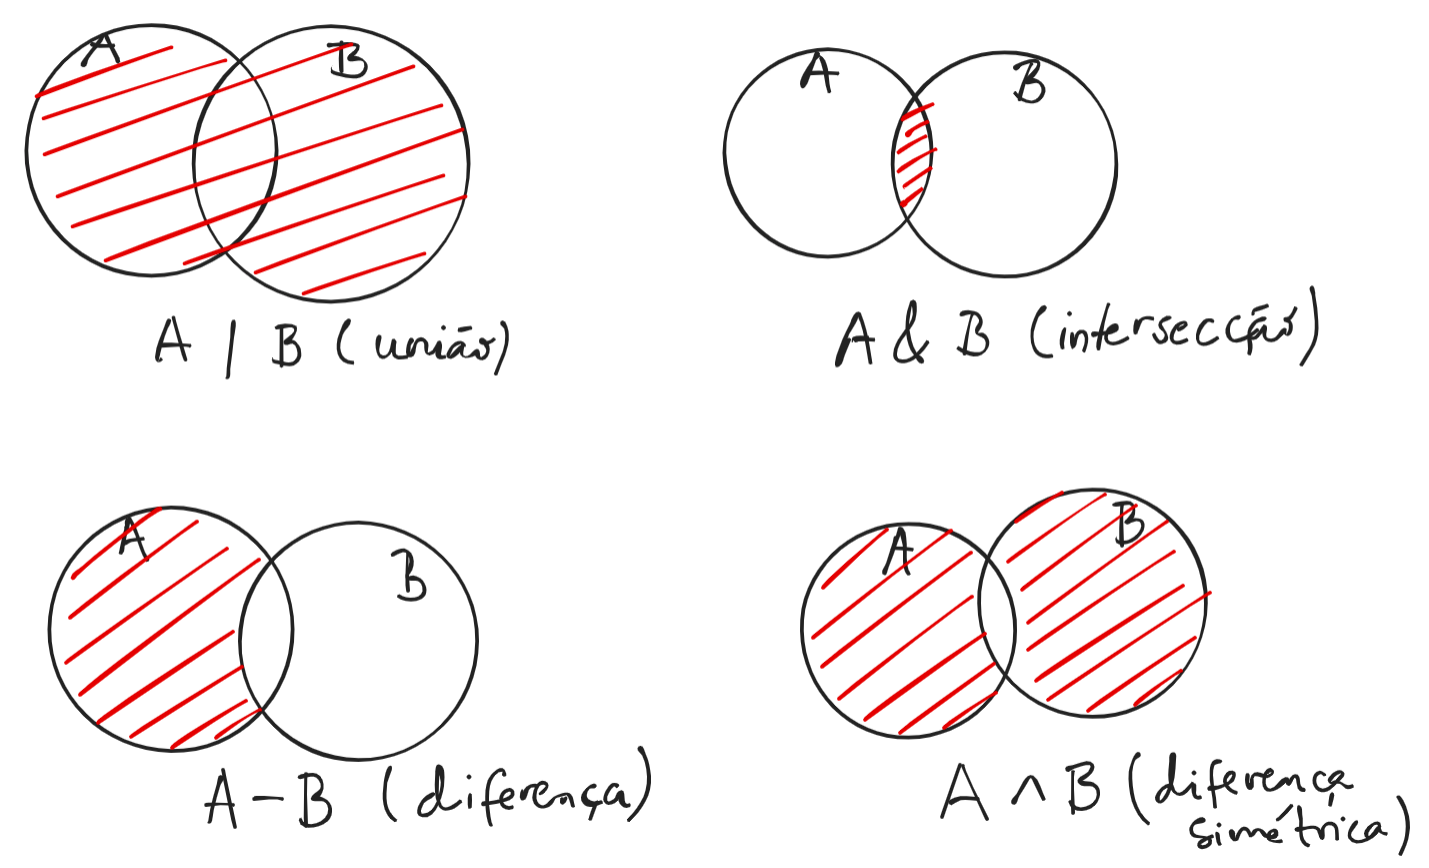


In [ ]:
mamiferos = {'cachorro', 'gato', 'urso', 'leão', 'girafa', 'coelho'}
aves = {'falcão', 'águia', 'canário', 'periquito'}
peixes = {'tubarão', 'carpa', 'salmão', 'tilápia'}
domesticos = {'cachorro', 'periquito', 'canário', 'carpa', 'gato', 'coelho'}

In [ ]:
animais = mamiferos | aves | peixes  # união
print('Todos os animais:', animais)
selvagens = animais - domesticos  # diferença
print('Todos os animais selvagens:', selvagens)
mamiferosDomesticos = mamiferos & domesticos  # intersecção
print('Todos os mamíferos domésticos:', mamiferosDomesticos)
x = peixes ^ domesticos  # diferença simétrica
print('Peixes não-domésticos e outros animais domésticos:', x)

In [ ]:
print('Leão está na lista?', 'leão' in animais)
print('Zebra está na lista?', 'zebra' in animais)

Outra aplicação útil de conjuntos:

In [ ]:
equipe1 = ['João', 'Bruna', 'Marcos', 'Cíntia', 'Joaquim']
equipe2 = ['João', 'Carlos', 'Jaqueline', 'Marcos', 'Alan']
equipe3 = ['Winder', 'Thaís', 'Michelle', 'Alan', 'Bruna']
# criando um conjunto com todos os integrantes de todas as equipes, sem repetição
timeTodo = set(equipe1+equipe2+equipe3)
print(timeTodo, '\nSão', len(timeTodo), 'participantes')

In [ ]:
timeTodo[0]  # elementos de conjuntos não são acessíveis por índices

Vamos supor que queremos agora mostrar os elementos do time em ordem alfabética:

In [ ]:
listaTimeTodo = list(timeTodo)
listaTimeTodo.sort()
print(listaTimeTodo)

In [ ]:
for pessoa in timeTodo:
    print(f'{pessoa:15s}', end='')
    if pessoa in equipe1: print('Projeto 1', end='\t')
    if pessoa in equipe2: print('Projeto 2', end='\t')
    if pessoa in equipe3: print('Projeto 3', end='\t')
    print()

**Ideia da Luciana**

Usar conjuntos para descobrir se há CPF com todos os dígitos repetidos (inválido):

In [ ]:
cpf1 = [1,2,3,4,5,6,7,8,9,0,9]
cpf2 = [3,3,3,3,3,3,3,3,3,3,3]

if len( set(cpf1) ) == 1: print("CPF1: Todos repetidos")
else: print("CPF1: Não são todos repetidos")
print("Conjunto gerado:", set(cpf1))
if len( set(cpf2) ) == 1: print("CPF2: Todos repetidos")
else: print("CPF2: Não são todos repetidos")
print("Conjunto gerado:", set(cpf2))

**Dica ótima:**

[Vários e-books ótimos sobre Python do Al Sweigart!](http://inventwithpython.com/)

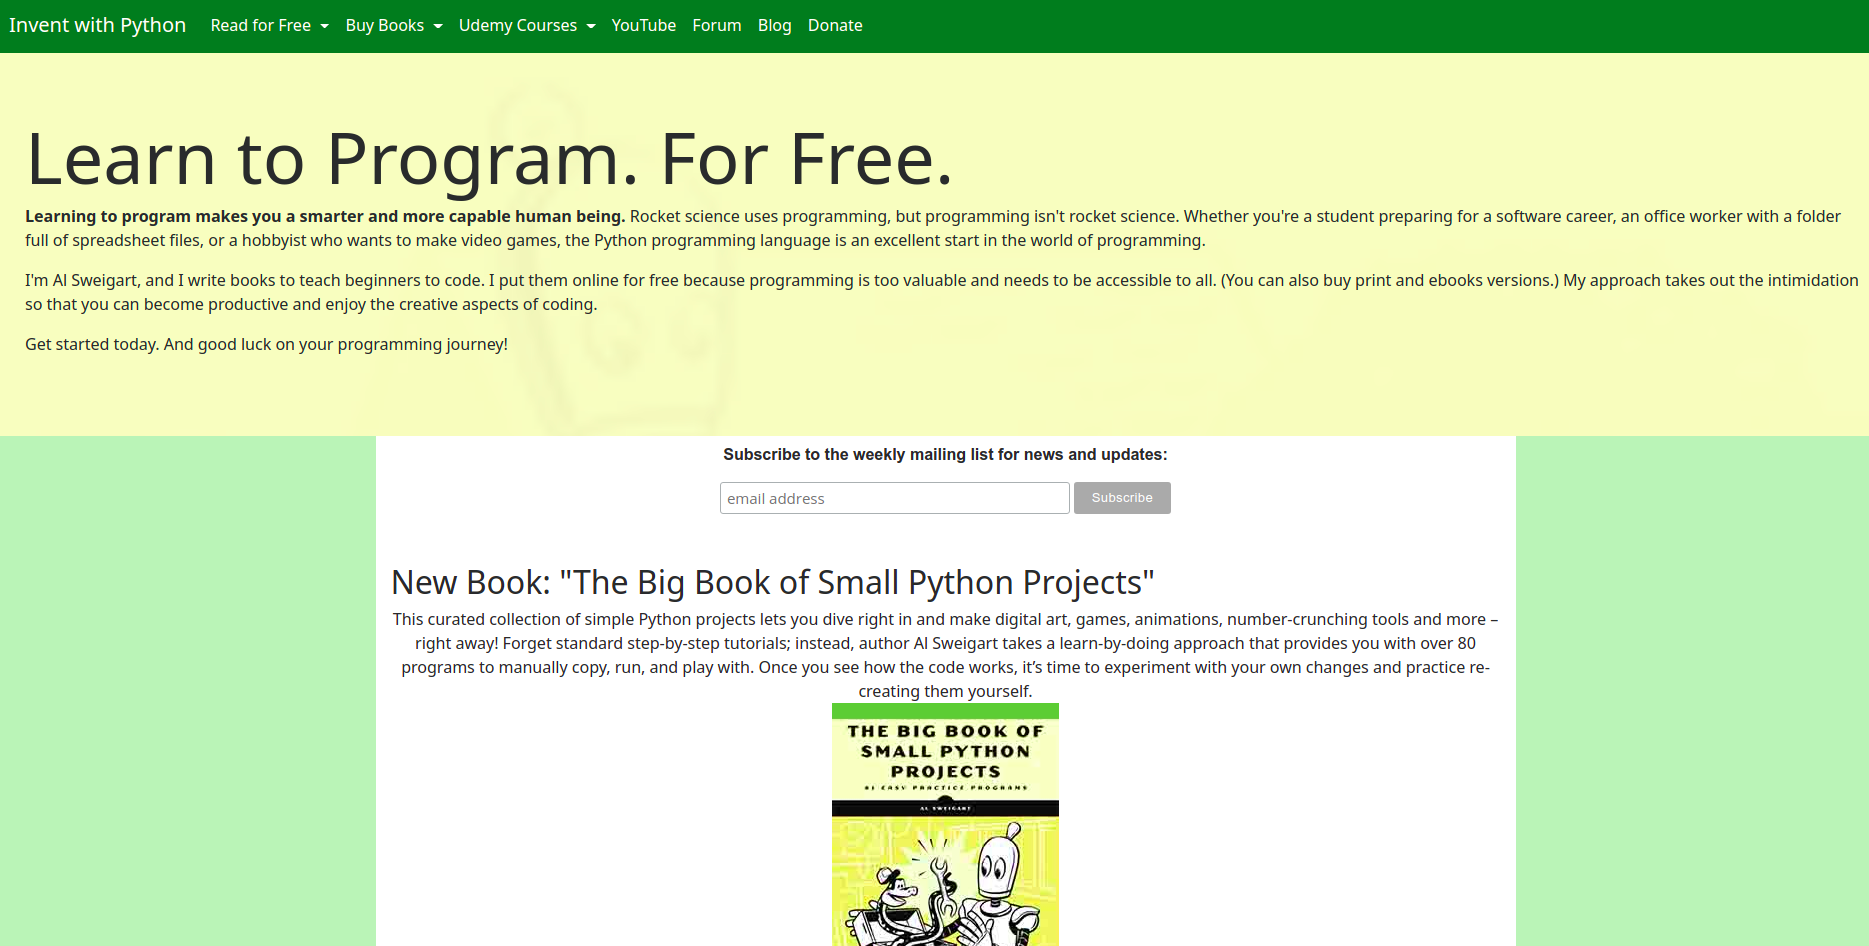

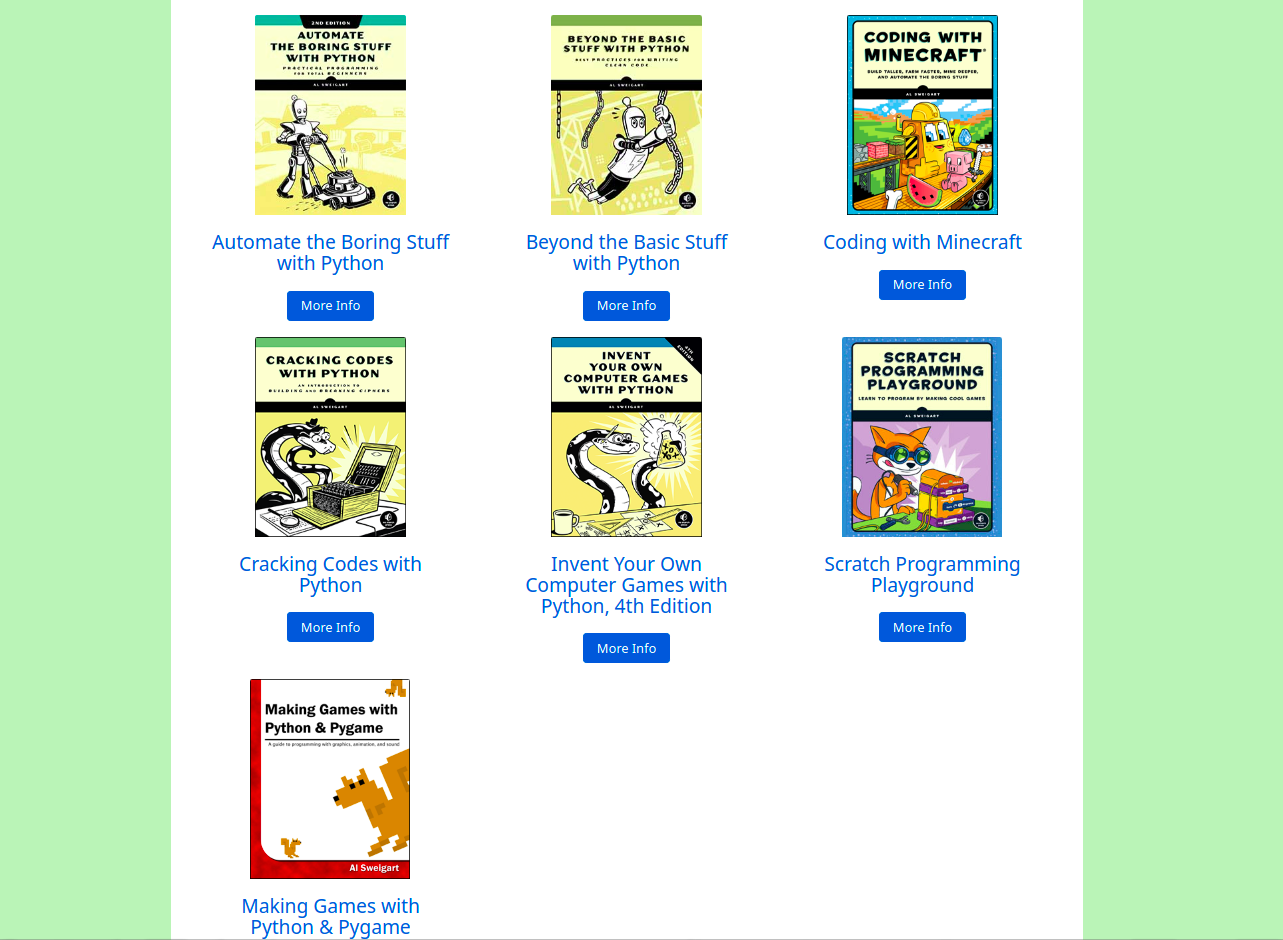

---
# **Exercícios:**

**Agora é hora de praticar:**

1) Vamos resolver o [problema "Botas Perdidas"](https://www.urionlinejudge.com.br/judge/pt/problems/view/1245) do site [URI](https://www.urionlinejudge.com.br):

**Botas Perdidas**

*Maratona de Programação da SBC Brasil 2011*

Timelimit: 1

A divisão de Suprimentos de Botas e Calçados do Exército comprou um grande número de pares de botas de vários tamanhos para seus soldados. No entanto, por uma falha de empacotamento da fábrica contratada, nem todas as caixas entregues continham um par de botas correto, com duas botas do mesmo tamanho, uma para cada pé. O sargento mandou que os recrutas retirassem todas as botas de todas as caixas para reembalá-las, desta vez corretamente.

Quando o sargento descobriu que você sabia programar, ele solicitou com a gentileza habitual que você escrevesse um programa que, dada a lista contendo a descrição de cada bota entregue, determina quantos pares corretos de botas poderão ser formados no total.

**Entrada**

A entrada é composta por diversos casos de teste e termina com final de arquivo (EOF). A primeira linha de um caso de teste contém um inteiro N (2 ≤ N ≤ 10^4), N é par, indicando o número de botas individuais entregues. Cada uma das N linhas seguintes descreve uma bota, contendo um número inteiro M (30 ≤ M ≤ 60) e uma letra L, separados por uma espaço em branco. M indica o número da bota e L indica o pé da bota: L = 'D' indica que a bota é para o pé direito, L = 'E' indica que a bota é para o pé esquerdo.

**Saída**

Para cada caso de teste imprima uma linha contendo um único número inteiro indicando o número total de pares corretos que podem ser formados.

**Exemplo de Entrada**

4

40 D

41 E

41 D

40 E

6

38 E

38 E

40 D

38 D

40 D

37 E


**Exemplo de Saída**

2

1


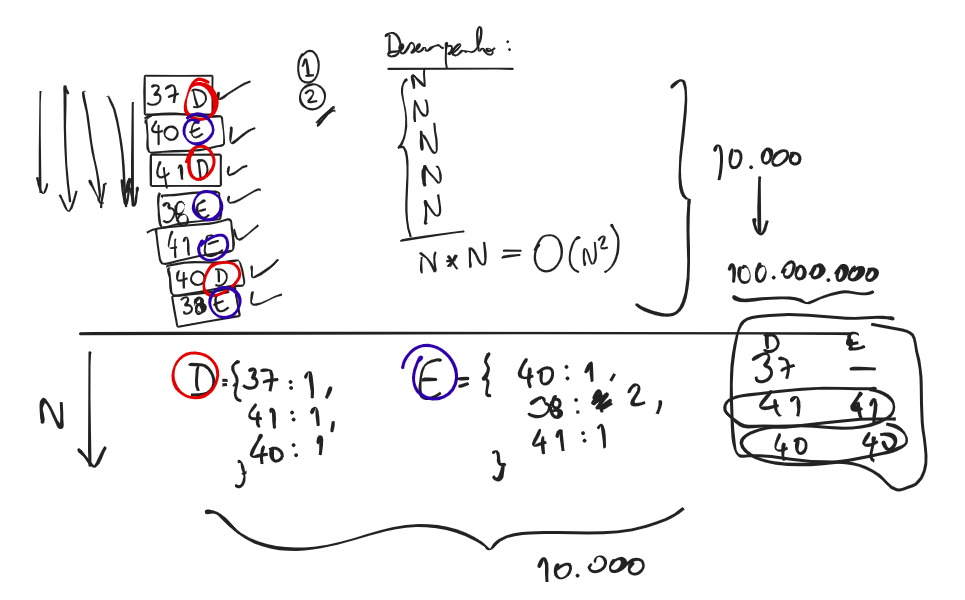

**Vamos resolver do jeito que rodaria mais lentamente:**

In [ ]:
numeros = []  # lista com os números de todas as botas
lados = []
numBotas = int(input())  # número total das botas
for i in range(numBotas):
  bota = input()  # por exemplo, '40 E'
  numeroLado = bota.split()  # no exemplo acima: ['40', 'E']
  numeros.append(numeroLado[0])  # no exemplo acima: '40' (primeiro elemento do vetor, índice 0)
  lados.append(numeroLado[1])  # no exemplo acima: 'E' (segundo elemento do vetor, índice 1)

print(numeros)
print(lados)

contPares = 0  # contagem dos pares formados
while numBotas > 0:
  encontreiPar = False
  for i in range(1, numBotas):
    if numeros[0] == numeros[i] and lados[0] != lados[i]:  # achei par!!
      print('Encontrei o par', numeros[0], lados[0], 'e', lados[i])
      contPares = contPares + 1
      numBotas = numBotas - 2
      encontreiPar = True
      del numeros[i]
      del lados[i]
      del numeros[0]
      del lados[0]
      break
  if encontreiPar == False:
    del numeros[0]
    del lados[0]
    numBotas = numBotas - 1

print(contPares, 'par(es) encontrado(s)')
print(numeros)
print(lados)

**Agora vamos resolver de um jeito mais eficiente, usando dicionários:**

In [ ]:
D = {}  # dicionário para pés direitos
E = {}  # dicionário para pés esquerdos
numBotas = int(input())  # número total das botas
for i in range(numBotas):
  bota = input()  # por exemplo, '40 E'
  numeroLado = bota.split()  # no exemplo acima: ['40', 'E']
  numero = numeroLado[0]  # no exemplo acima: '40' (primeiro elemento do vetor, índice 0)
  lado = numeroLado[1]  # no exemplo acima: 'E' (segundo elemento do vetor, índice 1)
  if lado == 'D':  # pé direito da bota
    if numero in D:  # número existe dentro deste dicionário?
      D[numero] = D[numero] + 1  # caso exista, soma um à quantidade de botas
    else:
      D[numero] = 1  # caso não exista, cria com valor igual a um (uma bota)

  else: # pé esquerdo da bota
    if numero in E:
      E[numero] = E[numero] + 1
    else:
      E[numero] = 1

print('Dicionário dos pés direitos: ', D)
print('Dicionário dos pés esquerdos: ', E)

quantidadePares = 0
for chaveD in D.keys(): # percorro todo o dicionário D e ...
  if chaveD in E: # comparo suas chaves com as do dicionário E
    quantidadePares = quantidadePares + min(D[chaveD], E[chaveD])

print(quantidadePares)

# **Agora, nosso tradutor 2.0**

Um rascunho para entendermos melhor uns comandos:

In [ ]:
dic = {}
dic['O'] = 'The'
dic['menino'] = 'boy'
dic['chutou'] = 'kicked'
dic['a'] = 'the'
dic['bola'] = 'ball'
texto = 'O menino chutou a bola'
palavras = texto.split()
print(palavras)
for p in palavras:
  print(dic[p], end=' ')

['O', 'menino', 'chutou', 'a', 'bola']
The boy kicked the ball 

In [ ]:
import pandas as pd
!wget https://raw.githubusercontent.com/cedmenezes/estudos/main/1000_palavras_ingles_portugues.csv
traducao = pd.read_csv('1000_palavras_ingles_portugues.csv', sep=';')
dic = {}
for i in range(traducao.shape[0]):
  linhaDaPlanilha = traducao.iloc[i]
  dic[linhaDaPlanilha['Palavra']] = linhaDaPlanilha['Tradução']

--2026-04-02 12:08:51--  https://raw.githubusercontent.com/cedmenezes/estudos/main/1000_palavras_ingles_portugues.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14419 (14K) [text/plain]
Saving to: ‘1000_palavras_ingles_portugues.csv’

1000_palavras_ingle 100%[===================>]  14.08K  --.-KB/s    in 0s      

2026-04-02 12:08:51 (28.5 MB/s) - ‘1000_palavras_ingles_portugues.csv’ saved [14419/14419]



In [ ]:
entrada = input('Entre com a sentença a traduzir (em inglês): ')
palavras = entrada.split()
for palavra in palavras:
  traducaoPt = dic.get(palavra, '#AUSENTE')
  if traducaoPt == '#AUSENTE': print(palavra, end=' ')
  else: print(traducaoPt, end=' ')

Entre com a sentença a traduzir (em inglês): lie
deitar, mentir 

#**Mini-Projeto**

Use o código abaixo, que está fazendo a raspagem dos dados do *site* da CBF, para descobrir, para cada clube de futebol:

- Número de vitórias em casa
- Número de derrotas em casa
- Número de vitórias fora
- Número de derrotas fora
- Saldo de gols em casa
- Saldo de gols fora
- Porcentagem de vitórias, empates e derrotas em casa
- Porcentagem de vitórias, empates e derrotas fora
- Número de pontos no campeonato, lembrando que vitória resulta em 3 pontos e o empate em 1 ponto.

In [ ]:
!pip install selenium chromedriver_autoinstaller

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.7/512.7 kB 44.3 MB/s eta 0:00:00


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import json
import chromedriver_autoinstaller


def processa_jogo(rodada, jogo):
    try:
        linhas = jogo.split('\n')
        time_casa = linhas[0]
        gols_casa = int(linhas[1])
        time_adv = linhas[3]
        gols_adv = int(linhas[4])
        numero = int(linhas[5][5:])
        data = linhas[6][:10]
        horario = linhas[6][13:]
        cidade = linhas[7][:-5]
        estado = linhas[7][-2:]
        estadio = linhas[8]
        return {
            'rodada': rodada,
            'time_casa': time_casa,
            'gols_casa': gols_casa,
            'time_adv': time_adv,
            'gols_adv': gols_adv,
            'numero': numero,
            'data': data,
            'horario': horario,
            'cidade': cidade,
            'estado': estado,
            'estadio': estadio
        }
    except Exception:
        print('Problemas processando:', jogo.replace('\n', ', '))
        return None


opts = Options()
opts.add_argument("--headless")
opts.add_argument('--no-sandbox') # Disables sandboxing, necessary in Colab
opts.add_argument('--disable-dev-shm-usage') # Prevents issues with limited shared memory


driver = webdriver.Chrome(options=opts)
campeonato = []

try:
    driver.get("https://www.cbf.com.br/futebol-brasileiro/tabelas/campeonato-brasileiro/serie-a/2025")
    time.sleep(3)  # dá tempo do JS montar a tabela

    # concordar e continuar
    wait = WebDriverWait(driver, 10) # Wait for a maximum of 10 seconds
    element = wait.until(EC.element_to_be_clickable((By.XPATH, '//*[@id="body"]/div[6]/div/button[1]')))
    element.click()

    while True:
        # ler a rodada
        wait = WebDriverWait(driver, 10)  # Wait for a maximum of 10 seconds
        element = wait.until(EC.element_to_be_clickable((By.XPATH, '//*[@id="body"]/section[1]/div/aside/header/div[1]/select/option')))
        rodada = int(element.text[7:])

        wait = WebDriverWait(driver, 10)  # Wait for a maximum of 10 seconds
        elements = wait.until(EC.visibility_of_all_elements_located((By.XPATH, '//*[@id="body"]/section[1]/div/aside/div/div')))
        for jogo in elements:
            dic_jogo = processa_jogo(rodada, jogo.text)
            if dic_jogo is not None:
                campeonato.append(dic_jogo)

        if rodada > 1:
            # clico no botão "<-"
            wait = WebDriverWait(driver, 10) # Wait for a maximum of 10 seconds
            element = wait.until(EC.element_to_be_clickable((By.XPATH, '//*[@id="body"]/section[1]/div/aside/header/div[2]/button[1]')))
            element.click()
            time.sleep(3)  # espero carregar
        else:
            break
finally:
    driver.quit()

campeonato = sorted(campeonato, key=lambda x: x['numero'])
print(campeonato)
json_campeonato = json.dumps(campeonato, indent=4, ensure_ascii=False)
print(json_campeonato)


ModuleNotFoundError: No module named 'selenium'

In [ ]:
dic_clubes = {}
for jogo in campeonato:
  if not jogo['time_casa'] in dic_clubes:
    dic_clubes[ jogo['time_casa'] ] = {'pontos': 0}
  if not jogo['time_adv'] in dic_clubes:
    dic_clubes[ jogo['time_adv'] ] = {'pontos': 0}

  if jogo['gols_casa'] > jogo['gols_adv']:
    dic_clubes[ jogo['time_casa'] ]['pontos'] += 3
  elif jogo['gols_casa'] < jogo['gols_adv']:
    dic_clubes[ jogo['time_adv'] ]['pontos'] += 3
  else:  # empate
    dic_clubes[ jogo['time_casa'] ]['pontos'] += 1
    dic_clubes[ jogo['time_adv'] ]['pontos'] += 1

print(dic_clubes)
json_clubes = json.dumps(dic_clubes, indent=4, ensure_ascii=False)
print(json_clubes)

{'FLA': {'pontos': 55}, 'INT': {'pontos': 32}, 'VAS': {'pontos': 33}, 'SAN': {'pontos': 28}, 'PAL': {'pontos': 58}, 'BOT': {'pontos': 43}, 'SÃO': {'pontos': 38}, 'SPO': {'pontos': 16}, 'RED': {'pontos': 36}, 'CEA': {'pontos': 34}, 'CRU': {'pontos': 52}, 'MIR': {'pontos': 46}, 'GRÊ': {'pontos': 33}, 'ATL': {'pontos': 32}, 'BAH': {'pontos': 43}, 'COR': {'pontos': 33}, 'FOR': {'pontos': 24}, 'FLU': {'pontos': 38}, 'JUV': {'pontos': 23}, 'VIT': {'pontos': 25}}
{
    "FLA": {
        "pontos": 55
    },
    "INT": {
        "pontos": 32
    },
    "VAS": {
        "pontos": 33
    },
    "SAN": {
        "pontos": 28
    },
    "PAL": {
        "pontos": 58
    },
    "BOT": {
        "pontos": 43
    },
    "SÃO": {
        "pontos": 38
    },
    "SPO": {
        "pontos": 16
    },
    "RED": {
        "pontos": 36
    },
    "CEA": {
        "pontos": 34
    },
    "CRU": {
        "pontos": 52
    },
    "MIR": {
        "pontos": 46
    },
    "GRÊ": {
        "pontos": 33
    },
    

In [ ]:

classificacao_clubes = []
for clube, valorClube in dic_clubes.items():
  classificacao_clubes.append( (clube, valorClube['pontos']) )
classificacao_clubes = sorted(classificacao_clubes, key = lambda x:x[1], reverse=True)
print(classificacao_clubes)
json_classificacao = json.dumps(classificacao_clubes, indent=4, ensure_ascii=False)
print(json_classificacao)

[('PAL', 58), ('FLA', 55), ('CRU', 52), ('MIR', 46), ('BOT', 43), ('BAH', 43), ('SÃO', 38), ('FLU', 38), ('RED', 36), ('CEA', 34), ('VAS', 33), ('GRÊ', 33), ('COR', 33), ('INT', 32), ('ATL', 32), ('SAN', 28), ('VIT', 25), ('FOR', 24), ('JUV', 23), ('SPO', 16)]
[
    [
        "PAL",
        58
    ],
    [
        "FLA",
        55
    ],
    [
        "CRU",
        52
    ],
    [
        "MIR",
        46
    ],
    [
        "BOT",
        43
    ],
    [
        "BAH",
        43
    ],
    [
        "SÃO",
        38
    ],
    [
        "FLU",
        38
    ],
    [
        "RED",
        36
    ],
    [
        "CEA",
        34
    ],
    [
        "VAS",
        33
    ],
    [
        "GRÊ",
        33
    ],
    [
        "COR",
        33
    ],
    [
        "INT",
        32
    ],
    [
        "ATL",
        32
    ],
    [
        "SAN",
        28
    ],
    [
        "VIT",
        25
    ],
    [
        "FOR",
        24
    ],
    [
        "JUV",
        23
   